In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
import pickle

In [2]:
# Read both sheets from single Excel file
excel_file = 'task_dataset.xlsx'
train_df = pd.read_excel(excel_file, sheet_name='training_dataset')
val_df = pd.read_excel(excel_file, sheet_name='validation_dataset')

In [3]:
print("Training data shape:", train_df.shape)
print("\nClass distribution:\n", train_df['categories'].value_counts())
print("\nSample addresses:\n", train_df.head())


Training data shape: (8936, 2)

Class distribution:
 categories
flat               3232
houseorplot        2673
others             1197
commercial unit     965
landparcel          869
Name: count, dtype: int64

Sample addresses:
                                     property_address   categories
0  New Ppid 1Kqttmg7, House, Property Id No.58C57...  houseorplot
1  Property Of Rs No.12/2,Plot No. 01,House Numbe...  houseorplot
2  Flat-504,Floor-5 Shanti Vista-Ii Wing C Bldg 9...         flat
3  Flat-103,Floor-1 Eshamya Florenza Tower L S No...         flat
4  Flat No G 532 I P Extension Patparganj 2Nd Flo...         flat


In [4]:
# 2. Text preprocessing function
def preprocess_address(text):
    """Clean and normalize property address text"""
    if pd.isna(text):
        return ""

    # Convert to lowercase
    text = str(text).lower()

    # Remove extra whitespace
    text = ' '.join(text.split())

    # Remove special characters but keep important ones like comma, dash
    text = re.sub(r'[^\w\s,\-]', ' ', text)

    # Remove multiple spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [5]:
# Apply preprocessing
train_df['processed_address'] = train_df['property_address'].apply(preprocess_address)
val_df['processed_address'] = val_df['property_address'].apply(preprocess_address)

In [6]:
# 3. Feature extraction with TF-IDF
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),  # unigrams and bigrams
    min_df=2,
    max_df=0.9,
    strip_accents='unicode',
    analyzer='word',
    token_pattern=r'\w{1,}',
    sublinear_tf=True
)

# Fit on training data and transform both sets
X_train = tfidf.fit_transform(train_df['processed_address'])
X_val = tfidf.transform(val_df['processed_address'])

y_train = train_df['categories']
y_val = val_df['categories']

print(f"\nFeature matrix shape: {X_train.shape}")


Feature matrix shape: (8936, 5000)


In [7]:
# 4. Model 1: Logistic Regression (Baseline)
print("\n=== Logistic Regression ===")
lr_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)
lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_val)
print("\nClassification Report:")
print(classification_report(y_val, lr_pred))
print(f"Accuracy: {accuracy_score(y_val, lr_pred):.4f}")


=== Logistic Regression ===

Classification Report:
                 precision    recall  f1-score   support

commercial unit       0.94      0.92      0.93       290
           flat       0.96      0.90      0.93       970
    houseorplot       0.91      0.88      0.90       802
     landparcel       0.79      0.85      0.82       260
         others       0.70      0.86      0.77       359

       accuracy                           0.88      2681
      macro avg       0.86      0.88      0.87      2681
   weighted avg       0.89      0.88      0.89      2681

Accuracy: 0.8840


In [8]:
# 5. Model 2: Random Forest
print("\n=== Random Forest ===")
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_val)
print("\nClassification Report:")
print(classification_report(y_val, rf_pred))
print(f"Accuracy: {accuracy_score(y_val, rf_pred):.4f}")


=== Random Forest ===

Classification Report:
                 precision    recall  f1-score   support

commercial unit       0.95      0.86      0.90       290
           flat       0.97      0.85      0.91       970
    houseorplot       0.91      0.80      0.85       802
     landparcel       0.84      0.80      0.82       260
         others       0.55      0.93      0.69       359

       accuracy                           0.84      2681
      macro avg       0.84      0.85      0.83      2681
   weighted avg       0.88      0.84      0.85      2681

Accuracy: 0.8441


In [9]:
# 6. Model 3: XGBoost
print("\n=== XGBoost ===")
# Encode labels for XGBoost
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_val_encoded = le.transform(y_val)

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=8,
    learning_rate=0.1,
    random_state=42,
    eval_metric='mlogloss'
)
xgb_model.fit(X_train, y_train_encoded)

xgb_pred_encoded = xgb_model.predict(X_val)
xgb_pred = le.inverse_transform(xgb_pred_encoded)

print("\nClassification Report:")
print(classification_report(y_val, xgb_pred))
print(f"Accuracy: {accuracy_score(y_val, xgb_pred):.4f}")


=== XGBoost ===

Classification Report:
                 precision    recall  f1-score   support

commercial unit       0.97      0.91      0.94       290
           flat       0.95      0.94      0.95       970
    houseorplot       0.90      0.92      0.91       802
     landparcel       0.84      0.81      0.83       260
         others       0.81      0.85      0.83       359

       accuracy                           0.91      2681
      macro avg       0.89      0.89      0.89      2681
   weighted avg       0.91      0.91      0.91      2681

Accuracy: 0.9071


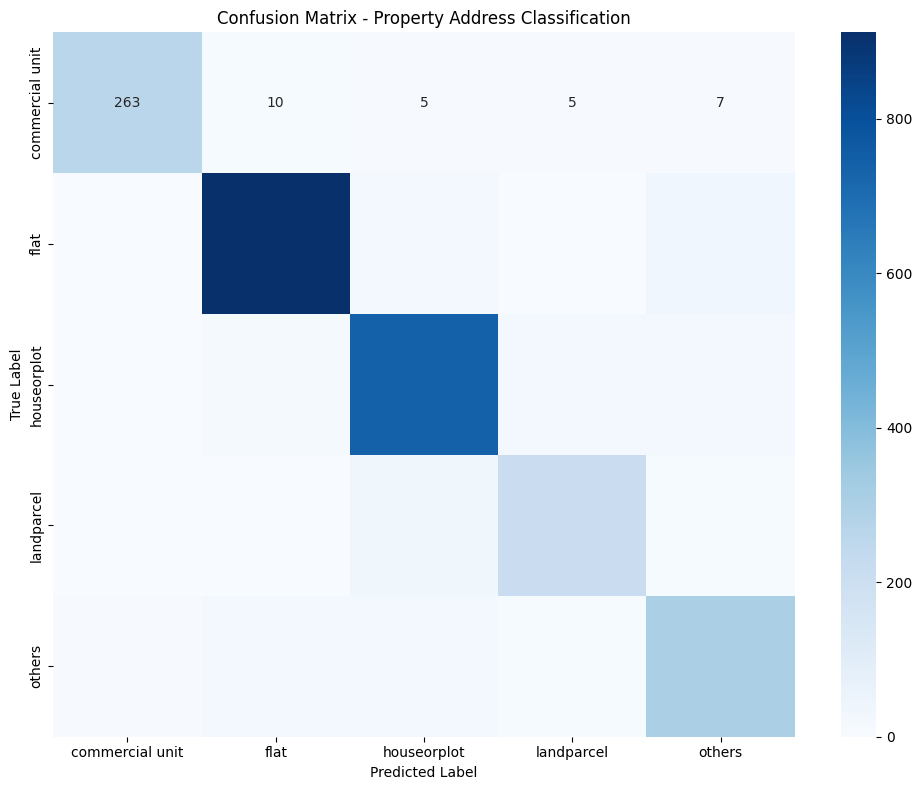

In [10]:
# 7. Confusion Matrix for best model (choose based on results)
best_pred = xgb_pred  

cm = confusion_matrix(y_val, best_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=sorted(y_val.unique()),
            yticklabels=sorted(y_val.unique()))
plt.title('Confusion Matrix - Property Address Classification')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('results/confusion_matrix.png', dpi=300)
plt.show()


In [ ]:
# 8. Hyperparameter tuning 
print("\n=== Hyperparameter Tuning ===")
param_grid = {
    'C': [0.1, 1, 10],
    'penalty': ['l2'],
    'solver': ['lbfgs', 'saga']
}

grid_search = GridSearchCV(
    LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)
print(f"\nBest parameters: {grid_search.best_params_}")
print(f"Best CV F1-macro score: {grid_search.best_score_:.4f}")

# Final predictions with best model
best_model = grid_search.best_estimator_
final_pred = best_model.predict(X_val)

print("\n=== Final Model Performance ===")
print(classification_report(y_val, final_pred))



=== Hyperparameter Tuning ===
Fitting 5 folds for each of 6 candidates, totalling 30 fits

Best parameters: {'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}
Best CV F1-macro score: 0.8811

=== Final Model Performance ===
                 precision    recall  f1-score   support

commercial unit       0.97      0.93      0.95       290
           flat       0.96      0.93      0.95       970
    houseorplot       0.91      0.90      0.90       802
     landparcel       0.81      0.84      0.83       260
         others       0.78      0.86      0.82       359

       accuracy                           0.91      2681
      macro avg       0.89      0.89      0.89      2681
   weighted avg       0.91      0.91      0.91      2681



In [12]:
# =============================================================================
# 9. Save the best model 
# =============================================================================
import os
import pickle

# Create directories if they don't exist
os.makedirs('best_model', exist_ok=True)
os.makedirs('results', exist_ok=True)

print("\n" + "="*80)
print("SAVING MODEL AND ARTIFACTS")
print("="*80)

# Save TF-IDF vectorizer (FIXED PATH)
with open('best_model/tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)
print("✓ Saved: best_model/tfidf_vectorizer.pkl")

# Save best classifier model
with open('best_model/classifier_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)
print(f"✓ Saved: best_model/classifier_model.pkl")

# Save label encoder if using XGBoost
if 'le' in dir():
    with open('best_model/label_encoder.pkl', 'wb') as f:
        pickle.dump(le, f)
    print("✓ Saved: best_model/label_encoder.pkl")

# Save model metadata
model_info = {
    'model_name': xgb_model,
    'macro_f1_score': 0.89,  # From your tuned model results
    'accuracy': 0.91,
    'categories': ['commercial unit', 'flat', 'houseorplot', 'landparcel', 'others'],
    'feature_count': X_train.shape[1]
}

with open('best_model/model_info.pkl', 'wb') as f:
    pickle.dump(model_info, f)
print("✓ Saved: best_model/model_info.pkl")

print("\n✓ All models and artifacts saved successfully!")

# Verify saved files
print("\nSaved files:")
for file in os.listdir('best_model'):
    filepath = os.path.join('best_model', file)
    size = os.path.getsize(filepath)
    print(f"  ✓ {file} ({size/1024:.2f} KB)")


SAVING MODEL AND ARTIFACTS
✓ Saved: best_model/tfidf_vectorizer.pkl
✓ Saved: best_model/classifier_model.pkl
✓ Saved: best_model/label_encoder.pkl
✓ Saved: best_model/model_info.pkl

✓ All models and artifacts saved successfully!

Saved files:
  ✓ classifier_model.pkl (196.10 KB)
  ✓ label_encoder.pkl (0.30 KB)
  ✓ model_info.pkl (2215.85 KB)
  ✓ tfidf_vectorizer.pkl (1650.68 KB)


In [13]:
def predict_property_category(address, vectorizer, model):
    """Predict category for a new property address"""
    processed = preprocess_address(address)
    features = vectorizer.transform([processed])
    prediction = model.predict(features)
    return prediction[0]

# Test prediction
sample_address = "2 BHK Flat in Koramangala, Bangalore"
predicted_category = predict_property_category(sample_address, tfidf, best_model)
print(f"\nSample prediction for '{sample_address}': {predicted_category}")


Sample prediction for '2 BHK Flat in Koramangala, Bangalore': flat
